In [ ]:
import os
import sys
sys.path.append(os.path.join('/simulation', 'code'))

import networkx as nx
import numpy as np
import pandas as pd

import pandapower
import re
import time

from lxml import etree

from meslf.networks.gas_network import GasNetwork, GasNode, GasLink, GasHalfLink
from meslf.networks.carrier import Gas
from meslf.networks.electrical_network import ElectricalNetwork, ElectricalNode, ElectricalLink, ElectricalHalfLink
from meslf.networks.heterogeneous_network import HeterogeneousNetwork, HeterogeneousNode
from meslf.utils.constants import bar, mbar, kV, MW

In [2]:
def convert_to_meter(value=0, unit="meter"):
    if unit in ["mm", "millimeter", "millimetre"]:
        return 10**-3 * value
    elif unit in ["cm", "centimeter", "centimetre"]:
        return 10**-2 * value
    elif unit in ["dm", "decimeter", "decimetre"]:
        return 10**-1 * value
    elif unit in ["m", "meter", "metre"]:
        return value
    elif unit in ["km", "kilometer", "kilometre"]:
        return 10**3 * value
    elif unit in ["in", "inch"]:
        return 0.0254 * value
    elif unit in ["ft", "foot"]:
        return 0.3048 * value
    else:
        raise ValueError("Unit '{}' not implemented or wrong".format(unit))

def convert_to_pa(value=0, unit="Pa"):
    if bool(re.match(r"\b[pP][aA]\b", unit)):
        return value
    elif bool(re.match(r"\b[mM][bB][aA][rR][aA]{0,1}", unit)):
        return 10**3 * value
    elif bool(re.match(r"\b[bB][aA][rR][aA]{0,1}\b", unit)):
        return 10**5 * value
    elif bool(re.match(r"\b[mM][bB][aA][rR][gG]", unit)):
        return 10**3 * value + 101325
    elif bool(re.match(r"\b[bB][aA][rR][gG]", unit)):
        return 10**5 * value + 101325
    else:
        raise ValueError("Unit '{}' not implemented or wrong".format(unit))

def convert_to_kg_per_second(value=0, rho=1, unit="kg_per_second"):
    if bool(re.match(r"\b[kK][gG]_[pP][eE][rR]_[sS][eE][cC][oO][nN][dD]\b", unit)) or bool(
            re.match(r"\b[kK][gG]\[sS]\b", unit)):
        return value
    if bool(re.match(r"\b[kK][gG]_[pP][eE][rR]_[hH][oO][uU][rR]\b", unit)):
        return value / 3600
    elif bool(re.match(r"\b[mM]_[cC][uU][bB][eE]_[pP][eE][rR]_[sS][eE][cC][oO][nN][dD]\b", unit)):
        return value * rho
    elif bool(re.match(r"\b[mM]_[cC][uU][bB][eE]_[pP][eE][rR]_[hH][oO][uU][rR]\b", unit)):
        return value * rho / 3600
    elif bool(re.match(r"\b1000[mM]_[cC][uU][bB][eE]_[pP][eE][rR]_[sS][eE][cC][oO][nN][dD]\b", unit)):
        return 1000 * value * rho
    elif bool(re.match(r"\b1000[mM]_[cC][uU][bB][eE]_[pP][eE][rR]_[hH][oO][uU][rR]\b", unit)):
        return 1000 * value * rho / 3600
    else:
        raise ValueError("Unit '{}' not implemented or wrong".format(unit))
    
def gaslib_get_tag(element):
    return element.tag.split("}")[-1]

def gaslib_to_pandas(path="GasLib-11"):
    # Convert GasLib topology data to Pandas dataframes
    xml = etree.parse(r"{}.net".format(path))

    node_data = []
    link_data = []

    for element in xml.findall("./*/*/[@id]"):
        element_storage = {}
        for key, value in element.attrib.items():
            element_storage[key] = value
        for element_child in element.iter():
            for key, value in element_child.attrib.items():
                if key == "unit":
                    key = "{}_unit".format(gaslib_get_tag(element_child))
                elif key == "value":
                    key = "{}_value".format(gaslib_get_tag(element_child))
                if bool(re.match(r".*_value\b", key)):
                    element_storage[key] = float(value)
                else:
                    element_storage[key] = value
        if gaslib_get_tag(element) in ["source", "sink", "innode"]:
            element_storage["node_type"] = gaslib_get_tag(element)
            node_data.append(element_storage)
        else:
            element_storage["link_type"] = gaslib_get_tag(element)
            link_data.append(element_storage)

    node_data = pd.DataFrame(node_data)
    link_data = pd.DataFrame(link_data)

    # Add boundary conditions to Pandas dataframe
    xml = etree.parse("{}.scn".format(path))

    column_names = ["q_min_value",
                    "q_min_unit",
                    "q_max_value",
                    "q_max_unit",
                    "p_min_value",
                    "p_min_unit",
                    "p_max_value",
                    "p_max_unit",
                    "contractPressureMax_value",
                    "contractPressureMax_unit"]
    node_data[column_names] = None

    node_data_id_list = list(node_data["id"])

    for element in xml.findall("./*/*/[@id]"):
        if element.attrib["id"] in node_data_id_list:
            index = node_data_id_list.index(element.attrib["id"])

            for element_child in element:
                if gaslib_get_tag(element_child) == "flow":
                    if element_child.attrib["bound"] == "both":
                        node_data.at[index, "q_min_value"] = float(element_child.attrib["value"])
                        node_data.at[index, "q_min_unit"] = element_child.attrib["unit"]
                        node_data.at[index, "q_max_value"] = float(element_child.attrib["value"])
                        node_data.at[index, "q_max_unit"] = element_child.attrib["unit"]
                    else:
                        if element_child.attrib["bound"] == "lower":
                            attrib = "min"
                        else:
                            attrib = "max"
                        node_data.at[index, "q_{}_value".format(attrib)] = float(element_child.attrib["value"])
                        node_data.at[index, "q_{}_unit".format(attrib)] = element_child.attrib["unit"]
                elif gaslib_get_tag(element_child) == "pressure":
                    if element_child.attrib["bound"] == "both":
                        node_data.at[index, "p_min_value"] = float(element_child.attrib["value"])
                        node_data.at[index, "p_min_unit"] = element_child.attrib["unit"]
                        node_data.at[index, "p_max_value"] = float(element_child.attrib["value"])
                        node_data.at[index, "p_max_unit"] = element_child.attrib["unit"]
                    else:
                        if element_child.attrib["bound"] == "lower":
                            attrib = "min"
                        else:
                            attrib = "max"
                        node_data.at[index, "p_{}_value".format(attrib)] = float(element_child.attrib["value"])
                        node_data.at[index, "p_{}_unit".format(attrib)] = element_child.attrib["unit"]
                elif gaslib_get_tag(element_child) == "contractPressureMax":
                    node_data.at[index, "contractPressureMax_value"] = float(element_child.attrib["value"])
                    node_data.at[index, "contractPressureMax_unit"] = element_child.attrib["unit"]

    return node_data, link_data

In [3]:
def create_network_gaslib(path, flow="average", pressure="max", link_eq_form="q_of_dp", network_name="GasLib-11", gas=None, q_inj_multiplier=1, no_slack=False):
    node_data, link_data = gaslib_to_pandas(path=path)

    # make first node a reference node based on the average of
    # pressureMin and pressureMax columns
    pressure_difference = node_data.pressureMax_value - node_data.pressureMin_value
    pressure_difference_max_indices = pressure_difference == pressure_difference.max()
    pressure_max_index = node_data.pressureMax_value[pressure_difference_max_indices].argmax()
    pressureMin = convert_to_pa(value=node_data.at[pressure_max_index, "pressureMin_value"],
                                unit=node_data.at[pressure_max_index, "pressureMin_unit"])
    pressureMax = convert_to_pa(value=node_data.at[pressure_max_index, "pressureMax_value"],
                                unit=node_data.at[pressure_max_index, "pressureMax_unit"])

    if no_slack:
        node_data.at[0, "node_type"] = "reference load"
        node_data.at[0, "q_min_value"] = 0
        node_data.at[0, "q_max_value"] = 0
    else:
        node_data.at[0, "node_type"] = "reference"
    
    node_data.at[0, "p_min_value"] = pressureMin  # 55*10**5  #
    node_data.at[0, "p_min_unit"] = "Pa"
    node_data.at[0, "p_max_value"] = pressureMax  # 55*10**5  #
    node_data.at[0, "p_max_unit"] = "Pa"
    network = GasNetwork(network_name)

    # nodes
    node_index = {}

    for i, name in enumerate(node_data.id):  # enumerate just in case if the nodes are not numbered in a standard way
        node_index[name] = i
        node_type = node_data.at[i, "node_type"]

        p_min_value = node_data.at[i, "p_min_value"]
        p_min_unit = node_data.at[i, "p_min_unit"]
        p_max_value = node_data.at[i, "p_max_value"]
        p_max_unit = node_data.at[i, "p_max_unit"]

        if pd.isna(p_min_value):
            p_min_value = 0
            node_data.at[i, "p_min_value"] = p_min_value
        if pd.isna(p_min_unit):
            p_min_unit = "Pa"
            node_data.at[i, "p_min_unit"] = p_min_unit
        if pd.isna(p_max_value):
            p_max_value = 0
            node_data.at[i, "p_max_value"] = p_max_value
        if pd.isna(p_max_unit):
            p_max_unit = "Pa"
            node_data.at[i, "p_max_unit"] = p_max_unit

        if pressure == "average":
            p = convert_to_pa(value=p_min_value, unit=p_min_unit) + \
                convert_to_pa(value=p_max_value, unit=p_max_unit)
            p *= 0.5
        elif pressure == "min":
            p = convert_to_pa(value=p_min_value, unit=p_min_unit)
        elif pressure == "max":
            p = convert_to_pa(value=p_max_value, unit=p_max_unit)
        else:
            raise ValueError("Invalid value encountered for input argument 'pressure'. " + \
                             "It must be 'average', 'min', or 'max', not '{}'".format(pressure))
            
        if node_type in ["reference load", "reference_sink", "reference_source", "sink", "source"]:
            q_min_value = node_data.at[i, "q_min_value"]
            q_min_unit = node_data.at[i, "q_min_unit"]
            q_max_value = node_data.at[i, "q_max_value"]
            q_max_unit = node_data.at[i, "q_max_unit"]

            if pd.isna(q_min_value):
                q_min_value = 0
                node_data.at[i, "q_min_value"] = q_min_value
            if pd.isna(q_min_unit):
                q_min_unit = "kg_per_second"
                node_data.at[i, "q_min_unit"] = q_min_unit
            if pd.isna(q_max_value):
                q_max_value = 0
                node_data.at[i, "q_max_value"] = q_max_value
            if pd.isna(q_max_unit):
                q_max_unit = "kg_per_second"
                node_data.at[i, "q_max_unit"] = q_max_unit

            if gas.name in ["hydrogen", "hydrogen gas", "hydrogen_gas", \
                            "Hydrogen", "Hydrogen Gas", "Hydrogen_Gas", \
                            "h2", "H2"]:
                rho = gas.rhon
            else:
                rho = node_data.at[i, "normDensity_value"]
                if pd.isna(rho):
                    rho = node_data["normDensity_value"].max()

            if flow == "average":
                q = convert_to_kg_per_second(value=q_min_value, rho=rho, unit=q_min_unit) + \
                    convert_to_kg_per_second(value=q_max_value, rho=rho, unit=q_max_unit)
                q *= 0.5
            elif flow == "min":
                q = convert_to_kg_per_second(value=q_min_value, rho=rho, unit=q_min_unit)
            elif flow == "max":
                q = convert_to_kg_per_second(value=q_max_value, rho=rho, unit=q_max_unit)
            else:
                raise ValueError("Invalid value encountered for input argument 'flow'. " + \
                                 "It must be 'average', 'min', or 'max', not '{}'".format(flow))

            if node_type in ["reference source", "source"]:
                q = -q
                
            q *= q_inj_multiplier

        if node_type in ["reference"]:
            node = GasNode(name="{}".format(name), 
                           x=node_data.at[i, "x"], 
                           y=node_data.at[i, "y"], 
                           node_type=0, p=p)
            network.add_node(node)
        elif node_type in ["reference load"]:
            node = GasNode(name="{}".format(name), 
                           x=node_data.at[i, "x"], 
                           y=node_data.at[i, "y"], 
                           node_type=3, p=p)
            network.add_node(node)
            half_link = GasHalfLink(name="half_link_{}".format(name), start_node=node, bc_type=1, q=q)
            network.add_half_link(half_link)
        elif node_type in ["junction", "innode"]:
            node = GasNode(name="{}".format(name), 
                           x=node_data.at[i, "x"], 
                           y=node_data.at[i, "y"], 
                           node_type=1)
            network.add_node(node)
            half_link = GasHalfLink(name="half_link_{}".format(name), start_node=node, bc_type=1, q=0)
            network.add_half_link(half_link)
        elif node_type in ["source", "sink"]:
            node = GasNode(name="{}".format(name), 
                           x=node_data.at[i, "x"], 
                           y=node_data.at[i, "y"], 
                           node_type=1)
            network.add_node(node)
            half_link = GasHalfLink(name="half_link_{}".format(name), start_node=node, bc_type=1, q=q)
            network.add_half_link(half_link)
        elif node_type in ["slack"]:
            node = GasNode(name="{}".format(name), 
                           x=node_data.at[i, "x"], 
                           y=node_data.at[i, "y"], 
                           node_type=2)
            network.add_node(node)
        else:
            raise ValueError("Node type called '{}' not implemented or wrong name".format(node_type))
        
    for i, name in enumerate(link_data.id):
        start_node = network.nodes[node_index[link_data.at[i, "from"]]]
        end_node = network.nodes[node_index[link_data.at[i, "to"]]]

        link_params = {"carrier" : gas}
                       
        if link_data.at[i, "link_type"] in ["compressorStation"]:
            link_type = "compressor"
            link_params["r"] = 1
        elif link_data.at[i, "link_type"] in ["controlValve", "valve"]:
            link_type = "resistor"
            link_params["C"] = 1
        elif link_data.at[i, "link_type"] in ["resistor"]:
            link_type = "resistor"
            link_params["C"] = 1
        elif link_data.at[i, "link_type"] in ["shortPipe"]:
            link_type = "resistor"
            link_params["C"] = 1
        else:
            link_type = "pipe_high_pres_weymouth"
            link_params["D"] = convert_to_meter(link_data.at[i, "diameter_value"], link_data.at[i, "diameter_unit"])
            link_params["L"] = convert_to_meter(link_data.at[i, "length_value"], link_data.at[i, "length_unit"])
            link_params["E"] = 1

        link = GasLink(name=name,
                       start_node=start_node,
                       end_node=end_node,
                       link_type=link_type,
                       link_params=link_params,
                       link_eq_form="dp_of_q")

        network.add_link(link)

    return network, node_data, link_data

In [4]:
def get_data(network_name):
    """
    Get data from pandapower based on the name of the network.

    Parameters
    ----------
        network_name : str
            Name of the network. Options:
                case4gs
                case5
                case6ww
                case9
                case14
                case24_ieee_rts
                case30
                case_ieee30
                case33bw
                case39
                case57
                case89pegase
                case118
                case145
                case_illinois200
                case300
                case1354pegase
                case1888rte
                case2848rte
                case2869pegase
                case3120sp
                case6470rte
                case6495rte
                case6515rte
                case9241pegase
                GBnetwork
                GBreducednetwork
                iceland

    Return
    ----------
        Return : pandapower.networks
            A pandapower network object
    """
    
    result = {}
    exec("data = pandapower.networks.{}()".format(network_name),
         globals(),
         result)
    return result["data"]

def find_node(name, network, node_names):
    return network.nodes[node_names.index(name)]

def compute_admittance(c_nf_per_km, f, g_us_per_km, length_km, parallel, r_ohm_per_km, x_ohm_per_km, Vn, Sn):
    Zn = Vn**2 / Sn
    r = r_ohm_per_km*length_km/parallel / Zn
    x = x_ohm_per_km*length_km/parallel / Zn
    
    b = -x / (r**2 + x**2)
    g = r / (r**2 + x**2)
    
    b_sh = 2*np.pi*f*c_nf_per_km*10**-9*length_km*parallel * Zn
    g_sh = g_us_per_km*10**-6*length_km*parallel * Zn

    return b, g, b_sh, g_sh

def compute_trafo(vn_hv_kv, vn_lv_kv, vn_kv_from, vn_kv_to, pfe_kw, i0_percent, vk_percent, vkr_percent, \
                  sn_mva, sn_mva_net, \
                  tap_neutral, tap_phase_shifter, tap_pos, tap_side, tap_step_degree, tap_step_percent, \
                  shift_degree):
    
    if (tap_phase_shifter == False) and (not np.isnan(tap_step_percent)) and (not np.isnan(tap_neutral)) and (not np.isnan(tap_pos)): # (tap_side in ['lv', 'hv']):
        n_tap = abs(1 + (tap_pos - tap_neutral) * tap_step_percent * 0.01)
        if tap_side == 'hv':
            vn_hv_kv *= n_tap
        elif tap_side =='lv':
            vn_lv_kv *= n_tap
            
    ratio = (vn_hv_kv / vn_lv_kv) * (vn_kv_to / vn_kv_from) 

    sn_ratio = sn_mva_net / sn_mva
    
    vn_ratio = (vn_kv_to / vn_lv_kv)**2
    
    Zn = vn_kv_to**2 / sn_mva_net
    Zn_trafo = vn_lv_kv**2 * sn_ratio

    vk_percent *= 0.01
    vkr_percent *= 0.01
    i0_percent *= 0.01

    r = vkr_percent * sn_ratio
    x = vk_percent * sn_ratio
    x = np.sign(vk_percent) * np.sqrt(x**2 - r**2)
    
    b = -x / (r**2 + x**2) * vn_ratio
    g = r / (r**2 + x**2) * vn_ratio

    g_sh = pfe_kw / (sn_mva * 1000) 
    b_sh = i0_percent**2 - g_sh**2
    if b_sh < 0:
        b_sh = 0
    b_sh = -np.sign(i0_percent) * np.sqrt(b_sh) * vn_ratio / sn_ratio
    g_sh *= vn_ratio / sn_ratio
             
    if False: # tap_phase_shifter:        
        if not np.isnan(tap_step_degree):
            shift_degree_tp = tap_step_degree*(tap_pos - tap_neutral)
        elif not np.isnan(tap_step_percent):
            shift_degree_tp = 2*np.arcsin(0.5*tap_step_percent*10**-2)*(tap_pos - tap_neutral)
        else:
            shift_degree_tp = 0
        
        phase_shift = (shift_degree + shift_degree_tp)*np.pi/180
    else:
        phase_shift = 0

    return b, g, b_sh, g_sh, ratio, phase_shift

def create_network_pandapower(network_name, ignore_nodes=[], no_slack=False):
    data = get_data(network_name)

    f = data.f_hz # default frequency

    network = ElectricalNetwork(network_name)
    
    node_name = ''
    node_names = []

    data.gen.loc[data.gen["sn_mva"].isnull(), 'sn_mva'] = data.sn_mva
    data.load.loc[data.load["sn_mva"].isnull(), 'sn_mva'] = data.sn_mva
    data.sgen.loc[data.sgen["sn_mva"].isnull(), 'sn_mva'] = data.sn_mva

    # slack node
    if no_slack:
        first = True
        for index, row in data.ext_grid.iterrows():
            if row["in_service"]:
                node_name = data.bus.loc[row['bus'], 'name']
                if node_name not in ignore_nodes:
                    if first:
                        network.add_node(ElectricalNode(name=node_name,
                                                        P=0,
                                                        V=row["vm_pu"],
                                                        delta=row["va_degree"]*np.pi/180,
                                                        node_type=3,
                                                        Sbase=data.sn_mva, # slack has no base complex power, so I set default to default of network
                                                        Vbase=data.bus.loc[row['bus'], 'vn_kv']))
                        first = False
                    else:
                        network.add_node(ElectricalNode(name=node_name,
                                                        V=row["vm_pu"],
                                                        delta=row["va_degree"]*np.pi/180,
                                                        node_type=0,
                                                        Sbase=data.sn_mva, # slack has no base complex power, so I set default to default of network
                                                        Vbase=data.bus.loc[row['bus'], 'vn_kv']))
                    node_names.append(node_name)
    else:
        for index, row in data.ext_grid.iterrows():
            if row["in_service"]:
                node_name = data.bus.loc[row['bus'], 'name']
                if node_name not in ignore_nodes:
                    network.add_node(ElectricalNode(name=node_name,
                                                    V=row["vm_pu"],
                                                    delta=row["va_degree"]*np.pi/180,
                                                    node_type=0,
                                                    Sbase=data.sn_mva, # slack has no base complex power, so I set default to default of network
                                                    Vbase=data.bus.loc[row['bus'], 'vn_kv']))
                    node_names.append(node_name)
                else:
                    print("Slack node is not included in network. This leads to an ill-posed system.")

    # PV node (P=-P, V=V)
    for index, row in data.gen.iterrows():
        if row["in_service"]:
            node_name = data.bus.loc[row['bus'], 'name']
            if node_name not in node_names + ignore_nodes:
                network.add_node(ElectricalNode(name=node_name,
                                                P=-row["p_mw"]/row["sn_mva"],
                                                V=row["vm_pu"],
                                                node_type=1,
                                                Sbase=row['sn_mva'],
                                                Vbase=data.bus.loc[row['bus'], 'vn_kv']))      
                node_names.append(data.bus.loc[row['bus'], 'name'])
            elif node_name in node_names:
                ElectricalHalfLink('{}_pv_{}_{}'.format(node_name, -row["p_mw"], row["vm_pu"]), 
                                find_node(node_name, network, node_names),
                                bc_type=2,
                                P=-row["p_mw"]/row["sn_mva"])

    # PQ node (static generator, P=-P, Q=-Q)
    for index, row in data.sgen.iterrows():
        if row["in_service"]:
            node_name = data.bus.loc[row['bus'], 'name']
            if node_name not in node_names + ignore_nodes:
                network.add_node(ElectricalNode(name=node_name,
                                                P=-row["p_mw"]/row["sn_mva"],
                                                Q=-row["q_mvar"]/row["sn_mva"],
                                                node_type=2,
                                                Sbase=row['sn_mva'],
                                                Vbase=data.bus.loc[row['bus'], 'vn_kv']))      
                node_names.append(data.bus.loc[row['bus'], 'name'])
            elif node_name in node_names:
                ElectricalHalfLink('{}_pq_{}_{}'.format(node_name, -row["p_mw"], -row["q_mvar"]), 
                                   find_node(node_name, network, node_names),
                                   bc_type=1,
                                   P=-row["p_mw"]/row["sn_mva"],
                                   Q=-row["q_mvar"]/row["sn_mva"])

    # Load (PQ node)
    for index, row in data.load.iterrows():
        if row["in_service"]:
            node_name = data.bus.loc[row['bus'], 'name']
            if node_name not in node_names + ignore_nodes:
                network.add_node(ElectricalNode(name=node_name,
                                                P=row["p_mw"]/row["sn_mva"],
                                                Q=row["q_mvar"]/row["sn_mva"],
                                                node_type=2,
                                                Sbase=row["sn_mva"],
                                                Vbase=data.bus.loc[row['bus'], 'vn_kv']))
                node_names.append(node_name)
            elif node_name in node_names:
                ElectricalHalfLink('{}_pq_{}_{}'.format(node_name, row["p_mw"], row["q_mvar"]), 
                                   find_node(node_name, network, node_names),
                                   bc_type=1,
                                   P=row["p_mw"]/row["sn_mva"], 
                                   Q=row["q_mvar"]/row["sn_mva"])
                        
    # Junction (PQ Node, P=0, Q=0)
    for index, row in data.bus.iterrows():
        if row['name'] not in node_names + ignore_nodes:
            network.add_node(ElectricalNode(name=row['name'],
                                            P=None,
                                            Q=None,
                                            node_type=2,
                                            Sbase=data.sn_mva,
                                            Vbase=row["vn_kv"]))
            node_names.append(row['name'])

    # Shunt (PQ Node, P=P, Q=-Q)
    for index, row in data.shunt.iterrows():
        if row["in_service"]:
            node_name = data.bus.loc[row['bus'], 'name']
            if node_name in node_names:
                P = row["p_mw"]*row["step"] / data.sn_mva
                Q = -row["q_mvar"]*row["step"] / data.sn_mva # injected reactive power
                y = (P + 1j*Q)
                ElectricalHalfLink('{}_shunt_{}_{}'.format(node_name, P, Q), 
                                   find_node(node_name, network, node_names),
                                   bc_type=1,
                                   P=P, 
                                   Q=Q,
                                   link_type='nodal_shunt',
                                   link_params={'b' : y.imag,
                                                'g' : y.real})

    # Line
    for index, row in data.line.iterrows():
        if row["in_service"]:
            from_bus = data.bus.loc[row["from_bus"], 'name']
            to_bus = data.bus.loc[row["to_bus"], 'name']
            if row["from_bus"] not in ignore_nodes and row["to_bus"] not in ignore_nodes:
                b, g, b_sh, g_sh = compute_admittance(c_nf_per_km=row["c_nf_per_km"],
                                                      f=f,
                                                      g_us_per_km=row["g_us_per_km"],
                                                      length_km=row["length_km"],
                                                      parallel=row["parallel"],
                                                      r_ohm_per_km=row["r_ohm_per_km"],
                                                      x_ohm_per_km=row["x_ohm_per_km"],
                                                      Vn=data.bus.loc[row["from_bus"]].vn_kv,
                                                      Sn=find_node(from_bus, network, node_names).Sbase)
                
                network.add_link(ElectricalLink(name="{}-{}".format(from_bus, to_bus),
                                                start_node=find_node(from_bus, network, node_names),
                                                end_node=find_node(to_bus, network, node_names),
                                                bc_type=0,
                                                link_type='pi_line',
                                                link_params={'b' : b,
                                                             'g' : g,
                                                             'b_sh' : b_sh,
                                                             'g_sh' : g_sh}))
            
    # Transformer
    for index, row in data.trafo.iterrows():
        if row["in_service"]:
            from_bus = data.bus.loc[row["hv_bus"], 'name']
            to_bus = data.bus.loc[row["lv_bus"], 'name']
            if row["hv_bus"] not in ignore_nodes and row["lv_bus"] not in ignore_nodes:
                b, g, b_sh, g_sh, ratio, phase_shift = compute_trafo(vn_hv_kv=row["vn_hv_kv"],
                                                                     vn_lv_kv=row["vn_lv_kv"],
                                                                     vn_kv_from=data.bus.loc[row["hv_bus"]].vn_kv,
                                                                     vn_kv_to=data.bus.loc[row["lv_bus"]].vn_kv,
                                                                     pfe_kw=row["pfe_kw"],
                                                                     i0_percent=row["i0_percent"],
                                                                     vk_percent=row["vk_percent"],
                                                                     vkr_percent=row["vkr_percent"],
                                                                     sn_mva=row["sn_mva"],
                                                                     sn_mva_net=data.sn_mva,
                                                                     tap_neutral=row["tap_neutral"],
                                                                     tap_phase_shifter=row["tap_phase_shifter"],
                                                                     tap_pos=row["tap_pos"],
                                                                     tap_side=row["tap_side"],
                                                                     tap_step_degree=row["tap_step_degree"],
                                                                     tap_step_percent=row["tap_step_percent"],
                                                                     shift_degree=row["shift_degree"])
                
                # print("{}-{} : g_sh = {}, b_sh = {}, ratio = {}".format(from_bus, to_bus, g_sh, b_sh, ratio))
                
                network.add_link(ElectricalLink(name="{}-{}".format(from_bus, to_bus),
                                                start_node=find_node(from_bus, network, node_names),
                                                end_node=find_node(to_bus, network, node_names),
                                                bc_type=0,
                                                link_type='pi_line_trafo',
                                                link_params={'b' : b,
                                                             'g' : g,
                                                             'b_sh' : b_sh,
                                                             'g_sh' : g_sh,
                                                             'ratio' : ratio,
                                                             'phase_shift' : phase_shift}))
                
    return network, data

  (0, 0)	1.0
  (0, 4)	-1.0
  (1, 0)	-1.0
  (1, 5)	-1.0
  (2, 0)	-1.5922446964824622e-06
  (2, 1)	2.0
  (3, 2)	1.9823734165140414e-05
  (3, 3)	4.11386485042735e-06
  (3, 7)	-1.0
  (4, 2)	3.964746833028083e-06
  (4, 3)	-1.9078144078144078e-05
  (5, 2)	-3.964746833028083e-06
  (5, 3)	2.0462818465011746e-05
  (6, 4)	-71.9928
  (6, 6)	1.0
  (7, 5)	-83.99159999999999
  (7, 7)	1.0
Iterations = 2
Residual = 8.133e-07


Text(0.5, 1.0, 'Residual 2-norm')

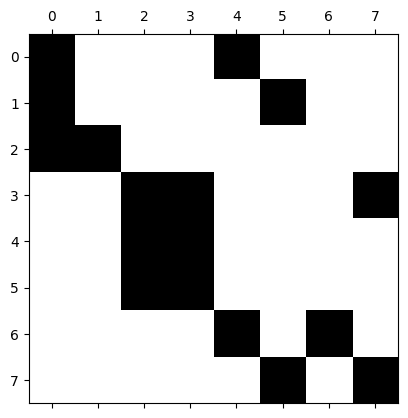

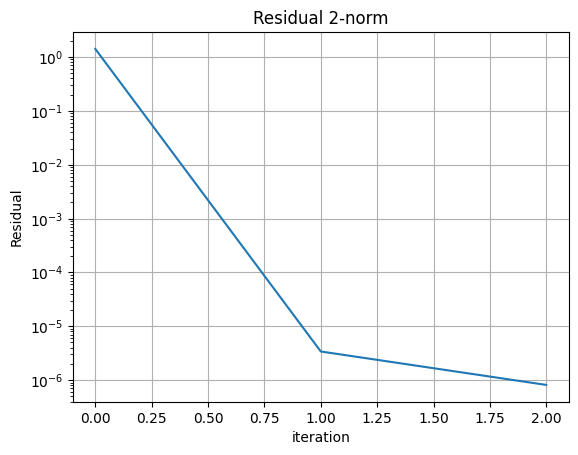

In [14]:
S = 0.0696 # This value to ensure equivalence between different pipe models
R = 8.314459848  # [J/molK]
M = 28.97e-3  # [kg/mol]
R_air = R/M  # [J/kgK]
Z = 1
pn = 101325 # [Pa]
Tn = 293.15 # [K]
T = Tn
gas = Gas('hydrogen gas', S, R_air, Z, pn, Tn, T)

LHV = 33.33*3600*10**3 # [MJ/kg]
HHV = 1.418*10**8 # 60134305 # [MJ/kg]

rho = gas.rhon
qbase = 1
pbase = 80 * bar



gas_network = GasNetwork('2node')

# g0 = GasNode(name='g0', node_type=0, p=pbase) # p
g0 = GasNode(name='g0', node_type=3, p=pbase, q=0) # pq
gas_network.add_node(g0)
g1 = GasNode(name='g1', node_type=1, q=-1) # q
gas_network.add_node(g1)

g1g0 = GasLink(name='g1g0', 
               start_node=g1, 
               end_node=g0, 
               link_type='pipe_high_pres_pole', 
               link_eq_form='dp_of_q',
               link_params={'D' : 1,
                            'L' : 1000,
                            'carrier' : gas})
gas_network.add_link(g1g0)



elec_network = ElectricalNetwork('2node')

e0 = ElectricalNode(name='e0', node_type=4, V=1, delta=0, Q=0) # QVdelta
# e0 = ElectricalNode(name='e0', node_type=5, P=0, Q=0, V=1, delta=0) # PQVdelta
elec_network.add_node(e0)
e1 = ElectricalNode(name='e1', node_type=2, P=1*LHV*0.7, Q=0) # PQ
elec_network.add_node(e1)

e0e1 = ElectricalLink(name='e0e1',
                      start_node=e0,
                      end_node=e1,
                      link_type='pi_line',
                      link_params={'b' : -19.078144078144078,
                                   'g' : 3.815628815628816,
                                   'b_sh' : 0.10250000000000001,
                                   'g_sh' : 0})
elec_network.add_link(e0e1)



het_network = HeterogeneousNetwork('2_gas_2_elec_2_gfg')

het_network.add_network(gas_network)
het_network.add_network(elec_network)

unit_type = 'ge_gas_fired_gen'
unit_params = {'eta': 0.6,
               'GHV': LHV}
c0 = HeterogeneousNode('c0',
                       node_type=1,
                       unit_type=unit_type,
                       unit_params=unit_params)
het_network.add_node(c0)

unit_params = {'eta': 0.7,
               'GHV': LHV}
c1 = HeterogeneousNode('c1',
                       node_type=1,
                       unit_type=unit_type,
                       unit_params=unit_params)
het_network.add_node(c1)

# dummy links
g0c0 = GasLink('g0c0', g0, c0)
gas_network.add_link(g0c0)
g1c1 = GasLink('g1c1', g1, c1)
gas_network.add_link(g1c1)

c0e0 = ElectricalLink('c0e0', c0, e0, bc_type=2, Qstart=0)
elec_network.add_link(c0e0)
c1e1 = ElectricalLink('c1e1', c1, e1, bc_type=2, Qstart=0)
elec_network.add_link(c1e1)



formulation = {'gas': 'full',
               'elec': 'complex_power',
               'het': None}

scale_var = 'per_unit'
scale_var_params = {'qbase': qbase,
                    'pbase': pbase,
                    'Sbase': MW,
                    'Vbase': 1,
                    'deltabase': 1,
                    'Ebase' : MW}

# formulation = "full"
# scale_var = "per_unit"
# scale_var_params = {"qbase": qbase, 
#                     "pbase": pbase}

# start solving
tol = 1e-6
max_iter = 20
solver = "NR"
optimal_multiplier = False
lin_solver = "direct"
lin_solver_parameters = {"block_size": (len(gas_network.links) + len(gas_network.nodes)) // 10,
                         "check_condition_number_p": False,
                         "check_eigenvalue_p": False,
                         "diag_pivot_thresh" : 0.1,
                         "drop_tol" : 1e-4,
                         "drop_rule" : ["basic", "area"],
                         "filename" : None,
                         "fill_factor": 1,
                         "max_iter": 100,
                         "nz_diag" : False,
                         "options" : {"Equil" : True},
                         "permc_spec": "colamd",
                         "preconditioner": "ilu",
                         "preconditioners_for_blocks": [],
                         "preconditioners_for_two_level": [],
                         "rcm" : False,
                         "residual": False,
                         "shift_value": 0,
                         "petsc_fill-in" : 5,
                         "petsc_gamgtype" : "classical",
                         "petsc_max_it": 100,
                         "petsc_nzdiag" : 0,
                         "petsc_nz_diag" : False,
                         "petsc_ord_type" : "qmd",
                         "petsc_preconditioner" : "ilu",
                         "petsc_reuse" : False,
                         "petsc_solver" : "gmres",
                         "petsc_zero_diagonal" : True}

return_all_x = False
check_condition_number = False
check_determinant = False
check_eigen = False
check_eigenvalue = False
check_J = True
check_rank = False
check_svd = False
check_symmetric = False

save_J = False

# initial gas flow
p_len = 0
q_len = 0
for element in het_network.get_x_entries(formulation=formulation)[1]:
    if isinstance(element, GasNode):
        p_len += 1
    elif isinstance(element, GasLink):
        q_len += 1
        
q_init = 0.1 * qbase * np.ones(q_len)

# initial pressure deviates from 5% to 10% of the reference pressure
p_ref = pbase
p_init = p_ref * np.linspace(0.95, 0.9, p_len)

# # update variables of class objects (nodes, links and terminal links)
# delta_init = np.zeros(len(het_network.get_x_entries(formulation=formulation)[3])) # flat start 0
# V_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[4])) # flat start 1
# qc_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[14])) # flat start 1
# Pc_init = MW*np.ones(len(het_network.get_x_entries(formulation=formulation)[16])) # flat start 1

q_init = [1]
p_init = [p_ref]
delta_init = [0]
V_init = [1.03908085e+00]
qc_init = [0, 1]
Pc_init = [0, LHV*0.7]

het_network.initialize()
het_network.update(np.concatenate([q_init, p_init, delta_init, V_init, qc_init, Pc_init]), formulation=formulation)

x_sol, iterations, residuals, p_g_vec, q_vec, q_inj, \
delta_vec, V_mag_vec, S_inj, P_edge, Q_edge, m_vec, \
p_h_vec, Ts_vec, Tr_vec, m_hl_vec, phi_hl_vec, Ts_hl_vec, \
Tr_hl_vec, qc_vec, Pc_vec, Qc_vec, mc_vec, phic_vec, \
Tsc_vec, Trc_vec = het_network.solve_network(tol=tol,
                                             max_iter=max_iter,
                                             solver=solver,
                                             formulation=formulation,
                                             scale_var=scale_var,
                                             scale_var_params=scale_var_params,
                                             check_J=check_J)


print("Iterations = {}".format(iterations))
print("Residual = {:1.3e}".format(residuals[-1]))

import matplotlib.pyplot as plt

plt.figure()
plt.semilogy(residuals)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("Residual")
plt.title("Residual 2-norm")

In [63]:
x_sol

array([-4.60215915e-08,  1.00000000e+00,  1.36898200e+14,  1.03908085e+00,
       -4.60215915e-08,  1.00000005e+00, -3.31322323e-06,  8.39916039e+01])

In [8]:
x_sol

array([-4.60215915e-08,  1.00000000e+00,  1.36898200e+14,  1.03908085e+00,
       -4.60215915e-08,  1.00000005e+00, -3.31322323e-06,  8.39916039e+01])

In [9]:
x_sol[2] % 2*np.pi

4.614214209960009

In [56]:
[q_init, p_init, delta_init, V_init, qc_init, Pc_init]

[[0], [8000000.0], [0], [1], [0, 0.1], [0, 41995800.0]]

In [12]:
for e in het_network.get_F_entries(formulation=formulation)[0]:
    print(e.name)

g0
g1
g1g0
e1
e0
e1
c0
c1


In [11]:
for e in het_network.get_x_entries(formulation=formulation)[0]:
    print(e.name)

g1g0
g1
e1
e1
g0c0
g1c1
c0e0
c1e1
